In [87]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [88]:
# Zakladni importy
import torch
from torch.optim.lr_scheduler import ReduceLROnPlateau
import numpy as np
import sys

In [89]:
# Import vlastnich modulu
sys.path.append("../..")
import src.data.cube_domain as cb
import src.models.expert_chars as ec
import src.models.mlp_model as mm
from src import train
from src import utils

In [90]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [91]:
L_BOUNDS = (0.0,)
U_BOUNDS = (2 * np.pi,)

L_BOUNDS_2D = (0.0, 0.0)
U_BOUNDS_2D = (2 * np.pi, 2 * np.pi)

In [92]:
domain_ctx = cb.CubeContext(
    l_bounds=L_BOUNDS,
    u_bounds=U_BOUNDS,
    dim=1,
    N_int=5000,
    N_sides=[(0, 0)],
    device=device,
    time_dependant=False
)

domain_ctx_2d = cb.CubeContext(
    l_bounds=L_BOUNDS_2D,
    u_bounds=U_BOUNDS_2D,
    dim=2,
    N_int=5000,
    N_sides=[(0, 0), (0, 0)],
    device=device,
    time_dependant=False,
)

domain_2d = cb.CubeDomain(domain_ctx_2d)
domain = cb.CubeDomain(domain_ctx)


### Preparing model contexts

In [93]:
model_disc_ctx = mm.ModelContext(
    l_bounds=L_BOUNDS,
    u_bounds=U_BOUNDS,
    layer=[32, 32, 64],
    input_dim=1,
    output_dim=1,
    has_discontinuity=True,
    last_layer_activation='disc'
)


model_smooth_ctx = mm.ModelContext(
    l_bounds=L_BOUNDS,
    u_bounds=U_BOUNDS,
    layer=[32, 32, 64],
    input_dim=1,
    output_dim=1,
    has_discontinuity=True,
    last_layer_activation='half_disc'
)

def char(x):
    return (x < np.pi/2).to(torch.float32)

model_expts_context = ec.PerCharCtx(
    input_dim=1,
    output_dims=[1, 1],
    hidden_layers_per_output=[[16, 16], [16, 16]],
    char_functions=[char],
    l_bounds=L_BOUNDS,
    u_bounds=U_BOUNDS
)

model_disc_g2_ctx = mm.ModelContext(
    l_bounds=L_BOUNDS_2D,
    u_bounds=U_BOUNDS_2D,
    layer=[32, 32, 64],
    input_dim=2,
    output_dim=1,
    has_discontinuity=True,
    last_layer_activation='disc',
)

model_smooth_g2_ctx = mm.ModelContext(
    l_bounds=L_BOUNDS_2D,
    u_bounds=U_BOUNDS_2D,
    layer=[32, 32, 64],
    input_dim=2,
    output_dim=1,
    has_discontinuity=True,
    last_layer_activation='half_disc',
)

def char_2d(xy):
    return (xy[:, 1:2] < (torch.pi + torch.sin(xy[:, 0:1]))).float()

model_expts_g2_ctx = ec.PerCharCtx(
    input_dim=2,
    output_dims=[1, 1],
    hidden_layers_per_output=[[16, 16], [16, 16]],
    char_functions=[char_2d],
    l_bounds=L_BOUNDS_2D,
    u_bounds=U_BOUNDS_2D,
)

model_disc = mm.MLPModel(model_disc_ctx).to(device)
model_smooth = mm.MLPModel(model_smooth_ctx).to(device)
model_ecp_ch = ec.PerCharModel(model_expts_context).to(device)


model_disc_g2   = mm.MLPModel(model_disc_g2_ctx).to(device)
model_smooth_g2 = mm.MLPModel(model_smooth_g2_ctx).to(device)
model_ecp_g2    = ec.PerCharModel(model_expts_g2_ctx).to(device)


model_disc_g1  = mm.MLPModel(model_disc_ctx).to(device)
model_smooth_g1 = mm.MLPModel(model_smooth_ctx).to(device)
model_ecp_g1   = ec.PerCharModel(model_expts_context).to(device)

optim_disc = torch.optim.Adam(model_disc.parameters(), lr=1e-4)
optim_smooth = torch.optim.Adam(model_smooth.parameters(), lr=1e-4)
optim_exp_ch = torch.optim.Adam(model_ecp_ch.parameters(), lr=1e-4)

In [94]:
import copy

# Deep-copy initial parameters for all models before any training occurs.
# Keyed by model name for easy lookup when comparing pre/post-training state.
initial_params: dict[str, dict[str, torch.Tensor]] = {
    "model_disc":     copy.deepcopy(model_disc.state_dict()),
    "model_smooth":   copy.deepcopy(model_smooth.state_dict()),
    "model_ecp_ch":   copy.deepcopy(model_ecp_ch.state_dict()),
    "model_disc_g1":  copy.deepcopy(model_disc_g1.state_dict()),
    "model_smooth_g1":copy.deepcopy(model_smooth_g1.state_dict()),
    "model_ecp_g1":   copy.deepcopy(model_ecp_g1.state_dict()),
    "model_disc_g2":  copy.deepcopy(model_disc_g2.state_dict()),
    "model_smooth_g2":copy.deepcopy(model_smooth_g2.state_dict()),
    "model_ecp_g2":   copy.deepcopy(model_ecp_g2.state_dict()),
}

print("Initial parameters saved for:", list(initial_params.keys()))


Initial parameters saved for: ['model_disc', 'model_smooth', 'model_ecp_ch', 'model_disc_g1', 'model_smooth_g1', 'model_ecp_g1', 'model_disc_g2', 'model_smooth_g2', 'model_ecp_g2']


In [95]:
def H(x):
    return torch.where(x < 0, 0, 1)

def f1(x):
    return x

def f2(x):
    return -torch.sin(x) - 2

def g(x):
    return char(x) * f1(x) + (1 - char(x)) * f2(x)


def g1(x: torch.Tensor) -> torch.Tensor:
    c1 = (x < torch.pi / 2).float()
    c2 = ((x >= torch.pi / 2) & (x < torch.pi)).float()
    c3 = ((x >= torch.pi) & (x < 3 * torch.pi / 2)).float()
    c4 = (x >= 3 * torch.pi / 2).float()
    return (
        c1 * torch.sin(5 * x)
        + c2 * (torch.exp(x - torch.pi / 2) - 3.0)
        + c3 * (-torch.cos(3 * x) + 2.0)
        + c4 * (x / torch.pi - 3.0)
    )

def g2(xy: torch.Tensor) -> torch.Tensor:
    x, y = xy[:, 0:1], xy[:, 1:2]
    interface = torch.pi + torch.sin(x)
    above = (y > interface).float()
    below = 1.0 - above
    return (
        above * (torch.sin(x) * torch.cos(y))
        + below * (-torch.exp(-((x - torch.pi) ** 2 + (y - torch.pi) ** 2) / 2.0) + 1.0)
    )


In [96]:
def loss(model: torch.nn.Module, domain: cb.CubeDomain):
    in_pts = domain.interior
    model_out = model(in_pts)
    g_out = g(in_pts)
    
    loss = torch.mean((model_out - g_out)**2)
    
    return [loss]


def loss_g1(model: torch.nn.Module, domain: cb.CubeDomain):
    """MSE loss against the 1-D four-region benchmark g1."""
    in_pts = domain.interior
    model_out = model(in_pts)
    target = g1(in_pts)
    return [torch.mean((model_out - target) ** 2)]


def loss_g2(model: torch.nn.Module, domain: cb.CubeDomain):
    """MSE loss against the 2-D curved-interface benchmark g2.
    Expects domain.interior to have shape (N, 2).
    """
    in_pts = domain.interior
    model_out = model(in_pts)
    target = g2(in_pts)
    return [torch.mean((model_out - target) ** 2)]


In [97]:
EPOCHS_PER_TEST = 20_000

train_ctx = train.TrainingContext(
    model=model_disc,
    optimizer=optim_disc,
    domain=domain,
    loss_fn=loss,
    epochs=EPOCHS_PER_TEST
)
losses_disc, _ = train.simple_train(train_ctx)

train_ctx.model = model_smooth
train_ctx.optimizer = optim_smooth
losses_smooth, _ = train.simple_train(train_ctx)

train_ctx.model = model_ecp_ch
train_ctx.optimizer = optim_exp_ch
losses_expts, _ = train.simple_train(train_ctx)


train_ctx_g1 = train.TrainingContext(
    model=model_disc_g1,
    optimizer=torch.optim.Adam(model_disc_g1.parameters(), lr=1e-4),
    domain=domain,
    loss_fn=loss_g1,
    epochs=EPOCHS_PER_TEST,
)
losses_disc_g1, _  = train.simple_train(train_ctx_g1)

train_ctx_g1.model     = model_smooth_g1
train_ctx_g1.optimizer = torch.optim.Adam(model_smooth_g1.parameters(), lr=1e-4)
losses_smooth_g1, _ = train.simple_train(train_ctx_g1)

train_ctx_g1.model     = model_ecp_g1
train_ctx_g1.optimizer = torch.optim.Adam(model_ecp_g1.parameters(), lr=1e-4)
losses_expts_g1, _ = train.simple_train(train_ctx_g1)


train_ctx_g2 = train.TrainingContext(
    model=model_disc_g2,
    optimizer=torch.optim.Adam(model_disc_g2.parameters(), lr=1e-4),
    domain=domain_2d,
    loss_fn=loss_g2,
    epochs=EPOCHS_PER_TEST,
)
losses_disc_g2, _   = train.simple_train(train_ctx_g2)

train_ctx_g2.model     = model_smooth_g2
train_ctx_g2.optimizer = torch.optim.Adam(model_smooth_g2.parameters(), lr=1e-4)
losses_smooth_g2, _ = train.simple_train(train_ctx_g2)

train_ctx_g2.model     = model_ecp_g2
train_ctx_g2.optimizer = torch.optim.Adam(model_ecp_g2.parameters(), lr=1e-4)
losses_expts_g2, _ = train.simple_train(train_ctx_g2)


Loss at epoch 1 is: 2.9679150581359863. 
Loss at epoch 100 is: 1.8436414003372192. 
Loss at epoch 200 is: 1.3298298120498657. 
Loss at epoch 300 is: 1.199040412902832. 
Loss at epoch 400 is: 1.1542596817016602. 
Loss at epoch 500 is: 1.1089345216751099. 
Loss at epoch 600 is: 1.0359725952148438. 
Loss at epoch 700 is: 0.9266964793205261. 
Loss at epoch 800 is: 0.7685521841049194. 
Loss at epoch 900 is: 0.5894482135772705. 
Loss at epoch 1000 is: 0.4718300700187683. 
Loss at epoch 1100 is: 0.40231072902679443. 
Loss at epoch 1200 is: 0.3542821705341339. 
Loss at epoch 1300 is: 0.31300801038742065. 
Loss at epoch 1400 is: 0.29608601331710815. 
Loss at epoch 1500 is: 0.25673359632492065. 
Loss at epoch 1600 is: 0.22954045236110687. 
Loss at epoch 1700 is: 0.19832274317741394. 
Loss at epoch 1800 is: 0.1723645031452179. 
Loss at epoch 1900 is: 0.16140063107013702. 
Loss at epoch 2000 is: 0.1336793452501297. 
Loss at epoch 2100 is: 0.11680866032838821. 
Loss at epoch 2200 is: 0.108056195080

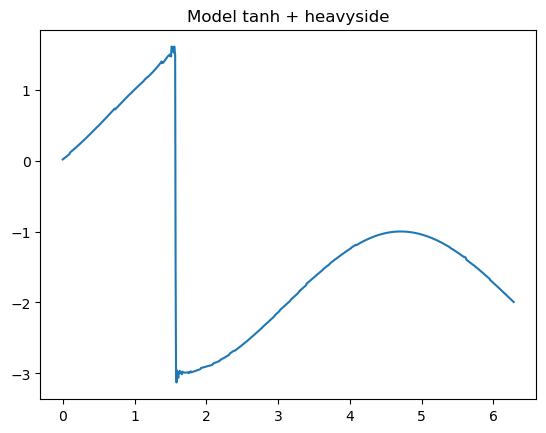

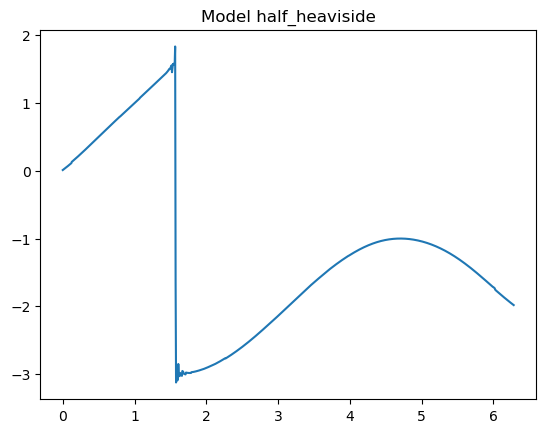

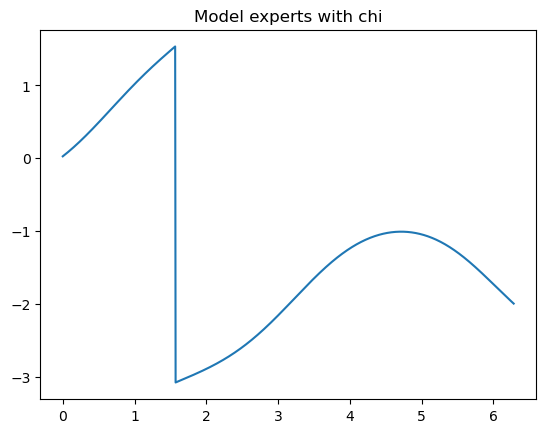

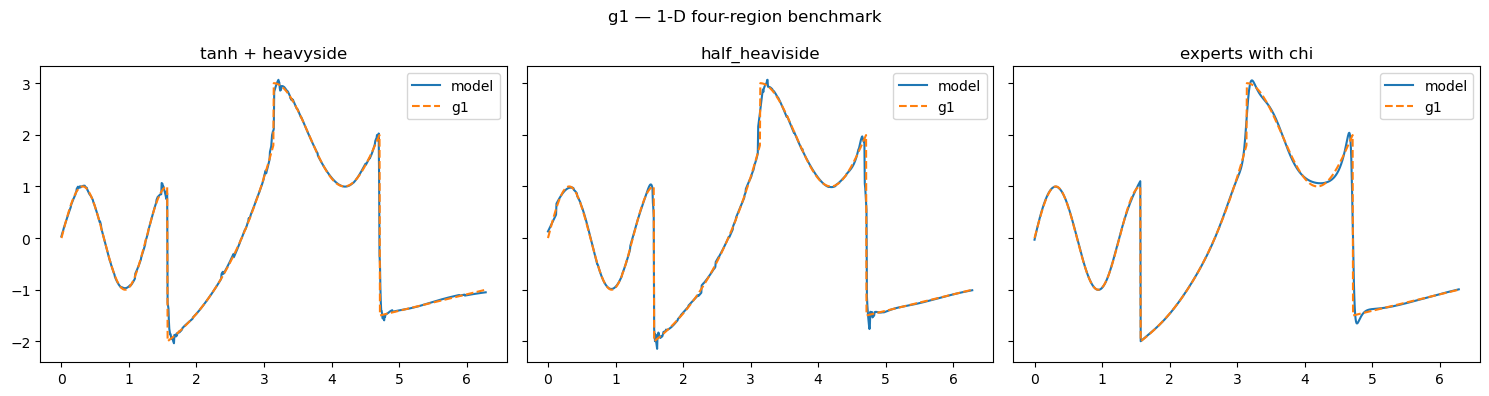

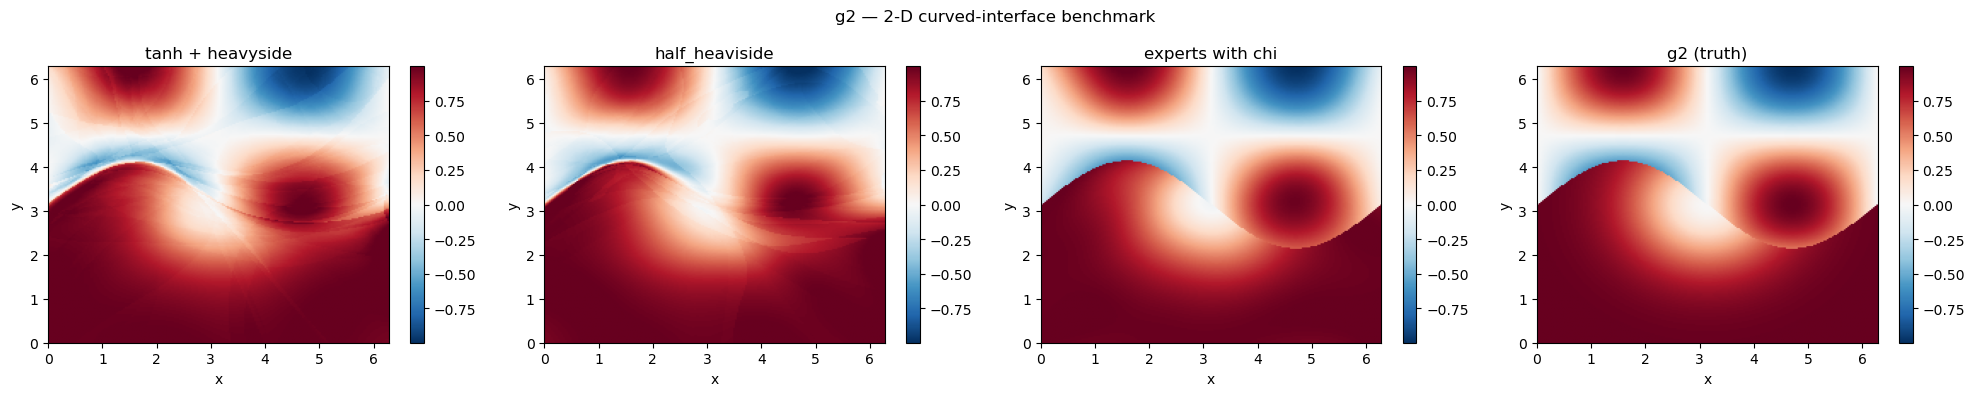

In [98]:
import matplotlib.pyplot as plt

x = torch.linspace(0, 2*np.pi, 1000, device=device).unsqueeze(1)

y_disc = model_disc(x).detach().to('cpu')
y_smooth = model_smooth(x).detach().to('cpu')
y_exp_ch = model_ecp_ch(x).detach().to('cpu')

y_g = g(x).detach().to('cpu')
x = x.detach().to('cpu')

fig_disc, ax_disc = plt.subplots()
fig_smooth, ax_smooth = plt.subplots()
fig_experts, ax_experts = plt.subplots()

ax_disc.set_title("Model tanh + heavyside")
ax_disc.plot(x, y_disc)
#ax_disc.plot(x, y_g)

ax_smooth.set_title("Model half_heaviside")
ax_smooth.plot(x, y_smooth)
#ax_smooth.plot(x, y_g)

ax_experts.set_title("Model experts with chi")
ax_experts.plot(x, y_exp_ch)

plt.show()


# ── g1: 1-D four-region benchmark ─────────────────────────────────────────────
x1 = torch.linspace(0, 2 * np.pi, 1000, device=device).unsqueeze(1)

y_disc_g1   = model_disc_g1(x1).detach().cpu()
y_smooth_g1 = model_smooth_g1(x1).detach().cpu()
y_ecp_g1    = model_ecp_g1(x1).detach().cpu()
y_g1_true   = g1(x1).detach().cpu()
x1_cpu      = x1.detach().cpu()

fig_g1, axes_g1 = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
fig_g1.suptitle("g1 — 1-D four-region benchmark")

axes_g1[0].set_title("tanh + heavyside")
axes_g1[0].plot(x1_cpu, y_disc_g1,   label="model")
axes_g1[0].plot(x1_cpu, y_g1_true,   label="g1", linestyle="--")
axes_g1[0].legend()

axes_g1[1].set_title("half_heaviside")
axes_g1[1].plot(x1_cpu, y_smooth_g1, label="model")
axes_g1[1].plot(x1_cpu, y_g1_true,   label="g1", linestyle="--")
axes_g1[1].legend()

axes_g1[2].set_title("experts with chi")
axes_g1[2].plot(x1_cpu, y_ecp_g1,    label="model")
axes_g1[2].plot(x1_cpu, y_g1_true,   label="g1", linestyle="--")
axes_g1[2].legend()

plt.tight_layout()
plt.show()


# ── g2: 2-D curved-interface benchmark ────────────────────────────────────────
N_grid = 200
xs = torch.linspace(0, 2 * np.pi, N_grid, device=device)
ys = torch.linspace(0, 2 * np.pi, N_grid, device=device)
grid_x, grid_y = torch.meshgrid(xs, ys, indexing="ij")          # (N, N)
xy_grid = torch.stack([grid_x.ravel(), grid_y.ravel()], dim=1)  # (N*N, 2)

with torch.no_grad():
    y_disc_g2_grid   = model_disc_g2(xy_grid).cpu().reshape(N_grid, N_grid)
    y_smooth_g2_grid = model_smooth_g2(xy_grid).cpu().reshape(N_grid, N_grid)
    y_ecp_g2_grid    = model_ecp_g2(xy_grid).cpu().reshape(N_grid, N_grid)
    y_g2_true_grid   = g2(xy_grid).cpu().reshape(N_grid, N_grid)

extent = [0, 2 * np.pi, 0, 2 * np.pi]
vmin = float(y_g2_true_grid.min())
vmax = float(y_g2_true_grid.max())

fig_g2, axes_g2 = plt.subplots(1, 4, figsize=(20, 4))
fig_g2.suptitle("g2 — 2-D curved-interface benchmark")

for ax, data, title in zip(
    axes_g2,
    [y_disc_g2_grid, y_smooth_g2_grid, y_ecp_g2_grid, y_g2_true_grid],
    ["tanh + heavyside", "half_heaviside", "experts with chi", "g2 (truth)"],
):
    im = ax.imshow(
        data.T, origin="lower", extent=extent,
        vmin=vmin, vmax=vmax, cmap="RdBu_r", aspect="auto",
    )
    ax.set_title(title)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    plt.colorbar(im, ax=ax)

plt.tight_layout()
plt.show()


In [99]:
from src.calculus import L2_norm

# Helper: wrap a model so it runs without gradient tracking
def eval_fn(model):
    def _fn(x):
        with torch.no_grad():
            return model(x)
    return _fn

# ── g: original 1-D benchmark ─────────────────────────────────────────────────
print("=== g (original 1-D) ===")
for name, model in [("tanh+heavyside", model_disc), ("half_heaviside", model_smooth), ("experts_chi", model_ecp_ch)]:
    err = L2_norm(eval_fn(model), g, input_dim=1, u_bounds=list(U_BOUNDS), l_bounds=list(L_BOUNDS), device=str(device))
    print(f"  {name:<20}  L2 = {err.item():.6f}")

# ── g1: 1-D four-region benchmark ─────────────────────────────────────────────
print("\n=== g1 (1-D four-region) ===")
for name, model in [("tanh+heavyside", model_disc_g1), ("half_heaviside", model_smooth_g1), ("experts_chi", model_ecp_g1)]:
    err = L2_norm(eval_fn(model), g1, input_dim=1, u_bounds=list(U_BOUNDS), l_bounds=list(L_BOUNDS), device=str(device))
    print(f"  {name:<20}  L2 = {err.item():.6f}")

# ── g2: 2-D curved-interface benchmark ────────────────────────────────────────
print("\n=== g2 (2-D curved interface) ===")
for name, model in [("tanh+heavyside", model_disc_g2), ("half_heaviside", model_smooth_g2), ("experts_chi", model_ecp_g2)]:
    err = L2_norm(eval_fn(model), g2, input_dim=2, u_bounds=list(U_BOUNDS_2D), l_bounds=list(L_BOUNDS_2D), device=str(device), n=100)
    print(f"  {name:<20}  L2 = {err.item():.6f}")


=== g (original 1-D) ===
  tanh+heavyside        L2 = 0.262790
  half_heaviside        L2 = 0.147337
  experts_chi           L2 = 0.031496

=== g1 (1-D four-region) ===
  tanh+heavyside        L2 = 0.347215
  half_heaviside        L2 = 0.351180
  experts_chi           L2 = 0.276456

=== g2 (2-D curved interface) ===
  tanh+heavyside        L2 = 0.335894
  half_heaviside        L2 = 0.334211
  experts_chi           L2 = 0.103831


In [100]:
def parameter_drift(model: torch.nn.Module, init_state: dict[str, torch.Tensor]) -> None:
    """Print the max absolute change per layer between init_state and current model weights."""
    current = model.state_dict()
    for layer_name in current:
        delta = (current[layer_name].float() - init_state[layer_name].float()).abs().max()
        print(f"    {layer_name:<45}  max|Δ| = {delta.item():.6f}")


models_and_keys = [
    # (display label,  model object,     key in initial_params)
    ("g  | tanh+heavyside", model_disc,      "model_disc"),
    ("g  | half_heaviside", model_smooth,    "model_smooth"),
    ("g  | experts_chi",    model_ecp_ch,    "model_ecp_ch"),
    ("g1 | tanh+heavyside", model_disc_g1,   "model_disc_g1"),
    ("g1 | half_heaviside", model_smooth_g1, "model_smooth_g1"),
    ("g1 | experts_chi",    model_ecp_g1,    "model_ecp_g1"),
    ("g2 | tanh+heavyside", model_disc_g2,   "model_disc_g2"),
    ("g2 | half_heaviside", model_smooth_g2, "model_smooth_g2"),
    ("g2 | experts_chi",    model_ecp_g2,    "model_ecp_g2"),
]

for label, model, key in models_and_keys:
    print(f"\n── {label} ──")
    parameter_drift(model, initial_params[key])



── g  | tanh+heavyside ──
    network.0.u_bounds                             max|Δ| = 0.000000
    network.0.l_bounds                             max|Δ| = 0.000000
    network.1.weight                               max|Δ| = 0.257256
    network.1.bias                                 max|Δ| = 0.200942
    network.3.weight                               max|Δ| = 0.248167
    network.3.bias                                 max|Δ| = 0.109847
    network.5.weight                               max|Δ| = 0.383830
    network.5.bias                                 max|Δ| = 0.114164
    network.6.jump_size                            max|Δ| = 0.630042
    network.6.jump_centre                          max|Δ| = 0.210424
    network.7.weight                               max|Δ| = 0.692643
    network.7.bias                                 max|Δ| = 0.130938
    network.8.jump_size                            max|Δ| = 0.959768
    network.8.jump_centre                          max|Δ| = 0.282189
    net